# Streaming | Prompt Chaining | Parallelization in langGraph

In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.X_AI_GROK_4_FAST
# model_str2_remote: str = RemoteModel.QWEN3_30B_A3B
model_str_local: str = LocalModel.LLAMA3_1_8B

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)


local_llm = ChatOpenAI(
    api_key=settings.LMSTUDIO_API_KEY.get_secret_value(),
    base_url=settings.LMSTUDIO_URL,
    temperature=0.0,
    model=model_str_local,
)

# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


# Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

[![image.png](https://i.postimg.cc/qqqR58h7/image.png)](https://postimg.cc/RJr43JTr)

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

In [6]:
from IPython.display import Image, Markdown, display
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

### Create A Simple Graph

In [7]:
class State(TypedDict):
    messages: Annotated[list[Any], add_messages]


async def call_llm(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    response = await remote_llm.ainvoke(input=state["messages"])

    return {"messages": [response]}

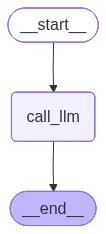

In [8]:
builder = StateGraph(State)

# Nodes
builder.add_node("call_llm", call_llm)

# Edges
builder.add_edge(START, "call_llm")
builder.add_edge("call_llm", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

### Normal Invocation

In [9]:
config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"messages": "Tell me a very short joke."},
    config=config,
)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Tell me a very short joke.
================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


### With Streaming

In [10]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

response = await graph.ainvoke(
    {"messages": "Tell me a very short joke."},
    config=config,
    stream_mode="updates",
)

for chunk in response:
    console.print(chunk)

{
    'call_llm': {
        'messages': [
            AIMessage(
                content='Why did the bicycle fall over? It was two-tired!',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 167,
                        'prompt_tokens': 190,
                        'total_tokens': 357,
                        'completion_tokens_details': {
                            'accepted_prediction_tokens': None,
                            'audio_tokens': None,
                            'reasoning_tokens': 154,
                            'rejected_prediction_tokens': None
                        },
                        'prompt_tokens_details': None
                    },
                    'model_name': 'x-ai/grok-4-fast',
                    'system_fingerprint': None,
                    'id': 'gen-1761676612-WIWcBrMng8UwOxTT6n2n',
                    'service_tier': None,
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='run--867e0a8f-debc-45bb-bd3d-e07a2dc6f43e-0',
                usage_metadata={
                    'input_tokens': 190,
                    'output_tokens': 167,
                    'total_tokens': 357,
                    'input_token_details': {},
                    'output_token_details': {'reasoning': 154}
                }
            )
        ]
    }
}

<br>

### Streaming The Responses With `astream_events` Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Contains langgraph_node, the node emitting the event.

- This is very useful for building custom UIs that need to show progress as the graph is being executed.

In [11]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

async for event in graph.astream_events(
    {"messages": "Tell me a very short joke."}, config=config
):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Tell me a very short joke.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': 'c1e1851b-9fe4-4c4b-906f-b4701febed8d', 'metadata': {'thread_id': '1'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Tell me a very short joke.', additional_kwargs={}, response_metadata={}, id='9edef71f-ebc9-437c-b44e-d0491e12dc56'), AIMessage(content="Why don't scientists trust atoms? Because they make up everything!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 163, 'total_tokens': 235, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 60, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_name': 'x-ai/grok-4-fast', 'system_fingerprint': None, 'id': 'gen-1761676611-WZax6jn6WzE91Malo4V8', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': No

In [12]:
async for event in graph.astream_events(
    {"messages": "Tell me a very short joke."}, config=config
):
    # To get the data associated with `on_chat_model_start` event (i.e. when the LLM starts generating tokens)
    if event["event"] == "on_chat_model_start":
        print("=== Model About To Start Token Generation ===")
        print(event["data"]["input"]["messages"])

        # `on_chat_model_stream` event (i.e. when the LLM starts streaming tokens)
        print("\n\n\n=== Generating Streaming Tokens ===")
    elif event["event"] == "on_chat_model_stream":
        print(event["data"]["chunk"].content)

    # `on_chat_model_end` event (i.e. when the LLM generated the full response tokens or is about to make tool call)
    elif event["event"] == "on_chat_model_end":
        print("=== Full Tokens Generated ===")
        print(event["data"]["output"].content)

    # `on_tool_end` event (i.e. when the LLM has generated the full response after making tool call)
    elif event["event"] == "on_tool_end":
        print("=== Full Tokens Generated After Toolcall===")
        print(event["data"]["output"].content)

=== Model About To Start Token Generation ===
[[HumanMessage(content='Tell me a very short joke.', additional_kwargs={}, response_metadata={}, id='9edef71f-ebc9-437c-b44e-d0491e12dc56'), AIMessage(content="Why don't scientists trust atoms? Because they make up everything!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 163, 'total_tokens': 235, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 60, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_name': 'x-ai/grok-4-fast', 'system_fingerprint': None, 'id': 'gen-1761676611-WZax6jn6WzE91Malo4V8', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--2fc42f63-ab62-46b6-abe9-906687fe9910-0', usage_metadata={'input_tokens': 163, 'output_tokens': 72, 'total_tokens': 235, 'input_token_details': {}, 'output_token_details': {'reasoning': 60}}), HumanMessage(content='Tell me 

# Prompt Chaining

- Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. 

- Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. 

- This approach can improve accuracy, coherence, and control when working with large language models.

- LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. 

- It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.

<br>

### How Prompt Chaining Works with LangGraph

1. **Define the Task**: Start by breaking down the problem into smaller sub-tasks. 
  - For example, if you want to generate a detailed report, you might split it into steps like `"gather data"`, `"analyze data"`, and `"write summary"`.

2. **Create Nodes**: Each sub-task becomes a node in the LangGraph structure. 
  - A node could be a prompt that instructs the model to perform a specific action, such as `"List key facts about X"` or `"Summarize the following text."`

3. **Establish Edges**: Edges define the sequence and dependencies between nodes. 
  - For instance, the output of the `"gather data"` node flows into the `"analyze data"` node, ensuring the model has the necessary context to proceed.

4. **Execute the Graph**: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. **Iterate if Needed**: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

### Example of Prompt Chaining with LangGraph

- Create a LangGraph that chains prompts to generate a story based on user input.

In [13]:
from pydantic import BaseModel, Field

type PydanticModel = type[BaseModel]
min_score: int = 1
max_score: int = 10


class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    score_info: dict[str, Any]
    runs: int
    final_story: str


class StoryScore(BaseModel):
    score: int = Field(
        ...,
        ge=min_score,
        le=max_score,
        description=f"Score from {min_score} (poor) to {max_score} (excellent)",
    )
    reason: str = Field(..., description="Reason for the score")


# ==================================================================
# ============================ PROMPTS =============================
# ==================================================================
create_story_prompt: str = """
<INSTR>
You're a storyteller. Create a short story of about 100 words about this 
<TOPIC>{topic}</TOPIC>
</INSTR> 
"""

create_improved_story_prompt: str = """
<INSTR>
You're a storyteller. Create an improved cohesive story of about 100 words using this 
<TOPIC>{topic}</TOPIC> <IMPROVEMENT_REASON>{reason}</IMPROVEMENT_REASON> 
and this initial story: <STORY>{story}</STORY>
Do NOT diverge from the topic.
</INSTR> 
"""

story_validator_prompt: str = """
<INSTR>
You are a strict story validator. Rate the story from {min_score} to {max_score}.

Evaluate <STORY>{story}</STORY> based on <TOPIC>{topic}</TOPIC>:

1. **Relevance (30%)** — Story directly addresses the topic
2. **Structure (20%)** — Clear beginning, middle, end with logical flow
3. **Clarity & Grammar (20%)** — No errors, precise language
4. **Creativity (15%)** — Original ideas, avoids clichés and generic phrases
5. **Engagement (15%)** — Compelling through vivid details or emotional resonance

Scoring rules:
- {max_score}: Flawless across ALL criteria (extremely rare)
- Deduct 1-2 points for each: cliché, grammar error, weak relevance, structural gap
- Any cliché or generic phrase caps creativity at 8/10 maximum
- Be harsh: average stories score 6-7, good stories 8, only exceptional stories 9+
- The final score should be closer to the LOWEST sub-score among the criteria

</INSTR>
"""

In [14]:
# ==================================================================
# ============================= LLMS ===============================
# ==================================================================
creative_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=1.25,
    model=RemoteModel.GEMINI_2_0_FLASH_001,
)
rigid_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
async def create_story(state: State) -> dict[str, Any]:
    prompt: str = create_story_prompt.format(topic=state["topic"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story": response.content}


async def rate_story(state: State) -> dict[str, Any]:
    prompt: str = story_validator_prompt.format(
        topic=state["topic"],
        min_score=min_score,
        max_score=max_score,
        story=state["story"],
    )
    llm_with_structured_output = rigid_llm.with_structured_output(StoryScore)
    response: PydanticModel = await llm_with_structured_output.ainvoke(input=prompt)
    return {
        "story": state["story"],
        "improved_story": state.get("improved_story", ""),
        "score_info": response.model_dump(),
    }


async def create_improved_story(state: State) -> dict[str, Any]:
    runs: int = state.get("runs", 0)
    state["runs"] = runs + 1
    prompt: str = create_improved_story_prompt.format(
        topic=state["topic"], reason=state["score_info"]["reason"], story=state["story"]
    )
    response = await creative_llm.ainvoke(input=prompt)
    return {
        "story": state["story"],
        "improved_story": response.content,
        "runs": state["runs"],
    }


def publish_story(state: State) -> dict[str, Any]:
    return {
        "final_story": (
            state["improved_story"] if state["improved_story"] else state["story"]
        )
    }


# Conditional node
def router(state: State) -> Literal["pass", "fail"]:
    score: int = state["score_info"].get("score", 1)
    runs: int = state.get("runs", 0)

    if score > 8 or runs >= 2:
        return "pass"
    return "fail"

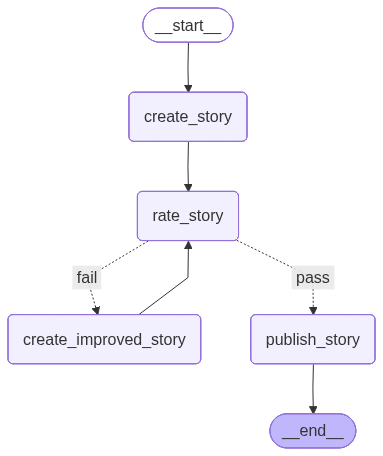

In [15]:
builder = StateGraph(State)

# Nodes
builder.add_node("create_story", create_story)
builder.add_node("rate_story", rate_story)
builder.add_node("create_improved_story", create_improved_story)
builder.add_node("publish_story", publish_story)


# Edges
builder.add_edge(START, "create_story")
builder.add_edge("create_story", "rate_story")
builder.add_conditional_edges(
    "rate_story",
    router,
    {
        "pass": "publish_story",
        "fail": "create_improved_story",
    },
)
builder.add_edge("create_improved_story", "rate_story")
builder.add_edge("publish_story", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [16]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"topic": "Tyrion Lannister's role in Game of Thrones"},
    config=config,
)

console.print(response)

{
    'topic': "Tyrion Lannister's role in Game of Thrones",
    'story': "The whispers followed Tyrion, the Imp. He was a Lannister, cursed and brilliant. From Hand to a king 
he helped murder, to Hand to a queen across the Narrow Sea, his sharp wit and strategic mind shaped Westeros. He 
saved King's Landing from Stannis, advised Dany through conquests, and ultimately, betrayed her, choosing reason 
over burning ambition. Was he hero or pragmatist? Tyrion, the survivor, knew only one truth: power was a fickle 
beast. He would become the Hand once more, this time to Bran the Broken, hoping his choices, stained with good 
intentions and dreadful consequences, would finally usher in a new era.\n",
    'improved_story': "Born a Lannister amidst scorn, Tyrion, the Imp, wielded his sharp wit as both shield and 
sword. He served as Hand, first saving King’s Landing from Stannis’s fiery assault. Across the Narrow Sea, he 
guided Daenerys, his counsel fueling her fiery reign. But the inferno threatened all, forcing Tyrion to choose: 
loyalty or the realm's survival? He chose the latter, a painful betrayal cloaked in pragmatism. Power, a dangerous 
game he knew well, demanded difficult choices. Now, Hand to Bran the Broken, Tyrion sought lasting peace, burdened 
by the weight of past decisions, hoping wisdom might finally triumph over Lannister's legacy.\n",
    'score_info': {
        'score': 6,
        'reason': "Relevance (9/10): Directly addresses Tyrion's roles and key events in Game of Thrones. Structure
(8/10): Logical flow from past to present with a clear arc. Clarity & Grammar (10/10): Precise, error-free 
language. Creativity (4/10): Largely a canon recap with clichéd phrases like 'sharp wit and strategic mind' and 
'power was a fickle beast,' lacking original ideas. Engagement (5/10): Informative but lacks vivid details or 
strong emotional pull. Final score pulled toward lowest sub-score (creativity) for an average summary-style story."
    },
    'runs': 2,
    'final_story': "Born a Lannister amidst scorn, Tyrion, the Imp, wielded his sharp wit as both shield and sword.
He served as Hand, first saving King’s Landing from Stannis’s fiery assault. Across the Narrow Sea, he guided 
Daenerys, his counsel fueling her fiery reign. But the inferno threatened all, forcing Tyrion to choose: loyalty or
the realm's survival? He chose the latter, a painful betrayal cloaked in pragmatism. Power, a dangerous game he 
knew well, demanded difficult choices. Now, Hand to Bran the Broken, Tyrion sought lasting peace, burdened by the 
weight of past decisions, hoping wisdom might finally triumph over Lannister's legacy.\n"
}

In [17]:
Markdown(response["final_story"])

Born a Lannister amidst scorn, Tyrion, the Imp, wielded his sharp wit as both shield and sword. He served as Hand, first saving King’s Landing from Stannis’s fiery assault. Across the Narrow Sea, he guided Daenerys, his counsel fueling her fiery reign. But the inferno threatened all, forcing Tyrion to choose: loyalty or the realm's survival? He chose the latter, a painful betrayal cloaked in pragmatism. Power, a dangerous game he knew well, demanded difficult choices. Now, Hand to Bran the Broken, Tyrion sought lasting peace, burdened by the weight of past decisions, hoping wisdom might finally triumph over Lannister's legacy.


# Parallelization

<br>

- In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don’t depend on each other’s outputs, you can run them in parallel. 

- This is achieved by:
  - Defining multiple nodes that can operate independently.

  - Connecting them to a common starting point (e.g., START or another node).

  - Merging their outputs into a downstream node if needed.

- LangGraph handles this implicitly when nodes are independent and can leverage multi-threading or asynchronous execution under the hood, depending on the runtime environment (e.g., Python’s asyncio or a multi-threaded executor).

<br>

<img src="https://i.postimg.cc/y8zhN4nX/image.png" width="400" alt="image">

### Parallelization Example

In [18]:
class State(TypedDict):
    topic_1: str
    topic_2: str
    topic_3: str

    story_1: str
    story_2: str
    story_3: str

    aggregated_story: str


story_prompt: str = """
<INSTR>You're a creative story teller. Write a short story of about 3 sentences using this 
<TOPIC>{topic}</TOPIC> 
</INSTR>
"""

story_aggregator_prompt: str = """
<INSTR>
You are a **skilled and disciplined story aggregator**. Your task is to merge and refine multiple stories into one cohesive narrative while preserving key ideas from each source.

Use the context below to craft the final output:
<CONTEXT>
    <STORY>{story_1}</STORY>
    <STORY>{story_2}</STORY>
    <STORY>{story_3}</STORY>
</CONTEXT>

<OUTPUT_FORMAT>
- Then, write a **final unified story** that merges the essence of all three into a **single, cohesive narrative of exactly three sentences**.
- Maintain clear transitions and logical flow between ideas.
- Ensure the final story reads smoothly, with consistent tone, tense, and perspective.
</OUTPUT_FORMAT>
</INSTR>
"""

In [19]:
# ==================================================================
# ============================= LLMS ===============================
# ==================================================================
creative_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.5,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# ==================================================================
# ============================= NODES ==============================
# ==================================================================
async def create_story_1(state: State) -> dict[str, Any]:
    prompt: str = story_prompt.format(topic=state["topic_1"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story_1": response.content}


async def create_story_2(state: State) -> dict[str, Any]:
    prompt: str = story_prompt.format(topic=state["topic_2"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story_2": response.content}


async def create_story_3(state: State) -> dict[str, Any]:
    prompt: str = story_prompt.format(topic=state["topic_3"])
    response = await creative_llm.ainvoke(input=prompt)
    return {"story_3": response.content}


async def aggregate_stories(state: State) -> dict[str, Any]:
    prompt: str = story_aggregator_prompt.format(
        story_1=state["story_1"],
        story_2=state["story_2"],
        story_3=state["story_3"],
    )
    response = await creative_llm.ainvoke(input=prompt)
    return {"aggregated_story": response.content}

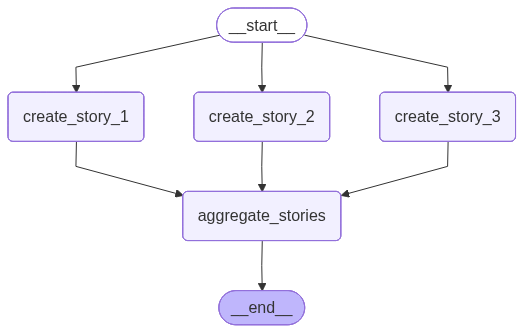

In [20]:
builder = StateGraph(State)

# Nodes
builder.add_node("create_story_1", create_story_1)
builder.add_node("create_story_2", create_story_2)
builder.add_node("create_story_3", create_story_3)
builder.add_node("aggregate_stories", aggregate_stories)


# Edges
builder.add_edge(START, "create_story_1")
builder.add_edge(START, "create_story_2")
builder.add_edge(START, "create_story_3")

builder.add_edge("create_story_1", "aggregate_stories")
builder.add_edge("create_story_2", "aggregate_stories")
builder.add_edge("create_story_3", "aggregate_stories")

builder.add_edge("aggregate_stories", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [21]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"topic_1": "Messi", "topic_2": "Cristiano Ronaldo", "topic_3": "Neymar Jr"},
    config=config,
)

console.print(response)

{
    'topic_1': 'Messi',
    'topic_2': 'Cristiano Ronaldo',
    'topic_3': 'Neymar Jr',
    'story_1': "In the bustling streets of Buenos Aires, young Lionel Messi chased a worn-out leather ball through 
alleyways, his tiny frame dodging vendors and stray dogs with effortless grace. One fateful evening, under the glow
of stadium lights, he scored a goal that silenced the roaring crowd and ignited a dream that would span continents.
Years later, as the world's greatest footballer, Messi looked back at that ball and smiled, knowing every dribble 
had been a step toward immortality.",
    'story_2': "In the bustling streets of Madeira, young Cristiano Ronaldo dreamed of glory on the pitch, honing 
his skills with a worn-out ball under the watchful eyes of his family. As he rose through the ranks at Sporting 
Lisbon and Manchester United, his unyielding determination turned doubters into believers, propelling him to become
one of football's greatest icons. On that fateful night in the Champions League final, with the world holding its 
breath, Ronaldo's soaring header sealed victory, etching his name eternally in the annals of the beautiful game.",
    'story_3': 'In the bustling streets of Rio de Janeiro, young Neymar Jr dribbled a worn-out soccer ball through 
the favela, his feet a blur of magic that turned every alley into a stadium. As scouts from Barcelona spotted his 
raw talent during a local match, he dreamed of lifting the World Cup, but little did he know that his flair would 
one day dazzle millions on the grandest stages. Years later, under the floodlights of the Camp Nou, Neymar scored a
breathtaking goal that echoed his humble beginnings, proving that true stardom is forged in passion and 
perseverance.',
    'aggregated_story': "In the bustling streets of Buenos Aires, Madeira, and Rio de Janeiro, young Lionel Messi, 
Cristiano Ronaldo, and Neymar Jr. each chased worn-out balls through alleyways and favelas, dodging obstacles with 
graceful determination under the watchful eyes of family and scouts, igniting dreams of glory that would transcend 
their humble origins. As they rose through the ranks—from Sporting Lisbon and Manchester United for Ronaldo, to 
Barcelona for Messi and Neymar—their unyielding perseverance turned doubters into believers, propelling them to 
dazzle millions on the world's grandest stages. Years later, under stadium floodlights, Messi's silencing goal, 
Ronaldo's soaring header in the Champions League final, and Neymar's breathtaking strike at the Camp Nou etched 
their names into football immortality, proving that every dribble from those early days forged paths to enduring 
stardom."
}

In [22]:
Markdown(response["aggregated_story"])

In the bustling streets of Buenos Aires, Madeira, and Rio de Janeiro, young Lionel Messi, Cristiano Ronaldo, and Neymar Jr. each chased worn-out balls through alleyways and favelas, dodging obstacles with graceful determination under the watchful eyes of family and scouts, igniting dreams of glory that would transcend their humble origins. As they rose through the ranks—from Sporting Lisbon and Manchester United for Ronaldo, to Barcelona for Messi and Neymar—their unyielding perseverance turned doubters into believers, propelling them to dazzle millions on the world's grandest stages. Years later, under stadium floodlights, Messi's silencing goal, Ronaldo's soaring header in the Champions League final, and Neymar's breathtaking strike at the Camp Nou etched their names into football immortality, proving that every dribble from those early days forged paths to enduring stardom.

### Key Benefits of Parallelization

- Speed: Reduces total execution time by running tasks concurrently.

- Scalability: Handles larger workflows efficiently.

- Modularity: Keeps the graph structure clean and reusable.

#### Key Takeaways
- When to Parallelize: Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

- Merging: Downstream nodes can aggregate parallel results.

- LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding.

